# Compressed-Air Digital Twin Validation

This notebook validates the pressure dynamics used by AeroXAI's compressed-air digital twin.

The model is **simulation-only evidence**.

It does not use MetroPT telemetry to estimate compressor energy, receiver volume, demand, leakage, or compressor capacity.

The governing equation is:

$$
\frac{dp}{dt}
=
\frac{RT}{V}
\left(
\dot m_{in}
-
\dot m_{demand}
-
\dot m_{leak}
\right)
$$

Internal SI units:

- pressure: Pa absolute
- temperature: K
- receiver volume: m³
- mass flow: kg/s
- time: s

The notebook reuses the already-tested physics implementation from `ml/twin/physics.py`; it does not duplicate the production physics logic.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()

if (
    not (ROOT / "ml").exists()
    and (ROOT.parent / "ml").exists()
):
    ROOT = ROOT.parent

if not (ROOT / "ml").exists():
    raise RuntimeError(
        "Could not locate repository root."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(ROOT),
    )

from ml.twin.physics import (
    TwinParameters,
    absolute_pa_to_bar_g,
    bar_g_to_absolute_pa,
    pressure_rate_pa_per_s,
    step_pressure,
)

print(
    "Repository root:",
    ROOT,
)

Repository root: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor


## Load the frozen simulation assumptions

The values in `configs/twin.yaml` are scenario assumptions for the simulated digital twin. They are not measurements from MetroPT or from a specific factory.

In [2]:
CONFIG_PATH = (
    ROOT
    / "configs"
    / "twin.yaml"
)

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as handle:
    config = yaml.safe_load(handle)

air_config = config["air"]
receiver_config = config["receiver"]
simulation_config = config["simulation"]

parameters = TwinParameters(
    volume_m3=float(
        receiver_config["volume_m3"]
    ),
    temperature_k=float(
        air_config["temperature_k"]
    ),
    gas_constant_j_per_kg_k=float(
        air_config[
            "gas_constant_j_per_kg_k"
        ]
    ),
    ambient_pressure_pa=float(
        air_config[
            "ambient_pressure_pa"
        ]
    ),
)

timestep_seconds = float(
    simulation_config[
        "timestep_seconds"
    ]
)

parameters

TwinParameters(volume_m3=10.0, temperature_k=298.15, gas_constant_j_per_kg_k=287.05, ambient_pressure_pa=101325.0)

## Scenario runner

The function below only orchestrates repeated calls to the tested `step_pressure()` physics function so that notebook scenarios can be reproduced consistently.

In [3]:
def simulate_constant_flow(
    *,
    duration_seconds: int,
    initial_pressure_bar_g: float,
    mass_flow_in_kg_s: float,
    demand_mass_flow_kg_s: float,
    leak_mass_flow_kg_s: float,
) -> pd.DataFrame:
    pressure_pa = (
        bar_g_to_absolute_pa(
            initial_pressure_bar_g,
            ambient_pressure_pa=(
                parameters
                .ambient_pressure_pa
            ),
        )
    )

    rows = [
        {
            "time_seconds": 0.0,
            "pressure_pa":
                pressure_pa,
            "pressure_bar_g":
                initial_pressure_bar_g,
        }
    ]

    steps = int(
        duration_seconds
        / timestep_seconds
    )

    for step in range(
        1,
        steps + 1,
    ):
        pressure_pa = step_pressure(
            pressure_pa=pressure_pa,
            mass_flow_in_kg_s=(
                mass_flow_in_kg_s
            ),
            demand_mass_flow_kg_s=(
                demand_mass_flow_kg_s
            ),
            leak_mass_flow_kg_s=(
                leak_mass_flow_kg_s
            ),
            timestep_seconds=(
                timestep_seconds
            ),
            parameters=parameters,
        )

        rows.append(
            {
                "time_seconds":
                    step
                    * timestep_seconds,
                "pressure_pa":
                    pressure_pa,
                "pressure_bar_g":
                    absolute_pa_to_bar_g(
                        pressure_pa,
                        ambient_pressure_pa=(
                            parameters
                            .ambient_pressure_pa
                        ),
                    ),
            }
        )

    return pd.DataFrame(rows)

## Balanced-flow validation

When compressor inflow exactly equals demand plus leakage,

$$
\dot m_{in}
=
\dot m_{demand}
+
\dot m_{leak},
$$

the model should produce $dp/dt = 0$ and therefore constant receiver pressure.

In [4]:
balanced = simulate_constant_flow(
    duration_seconds=600,
    initial_pressure_bar_g=7.0,
    mass_flow_in_kg_s=0.10,
    demand_mass_flow_kg_s=0.09,
    leak_mass_flow_kg_s=0.01,
)

balanced_change_bar = float(
    balanced[
        "pressure_bar_g"
    ].iloc[-1]
    - balanced[
        "pressure_bar_g"
    ].iloc[0]
)

print(
    "Balanced-flow pressure change:",
    balanced_change_bar,
    "bar",
)

balanced.tail()

Balanced-flow pressure change: 0.0 bar


,time_seconds,pressure_pa,pressure_bar_g
596,596.0,801325.0,7.0
597,597.0,801325.0,7.0
598,598.0,801325.0,7.0
599,599.0,801325.0,7.0
600,600.0,801325.0,7.0


## Controlled pressure rise and decay

Positive net mass flow should increase receiver pressure. Negative net mass flow should decrease it. The two scenarios below use equal and opposite mass-flow imbalance so their pressure-change magnitudes should be approximately symmetric.

In [5]:
pressure_rise = (
    simulate_constant_flow(
        duration_seconds=600,
        initial_pressure_bar_g=7.0,
        mass_flow_in_kg_s=0.12,
        demand_mass_flow_kg_s=0.09,
        leak_mass_flow_kg_s=0.01,
    )
)

pressure_decay = (
    simulate_constant_flow(
        duration_seconds=600,
        initial_pressure_bar_g=7.0,
        mass_flow_in_kg_s=0.08,
        demand_mass_flow_kg_s=0.09,
        leak_mass_flow_kg_s=0.01,
    )
)

rise_change = float(
    pressure_rise[
        "pressure_bar_g"
    ].iloc[-1]
    - pressure_rise[
        "pressure_bar_g"
    ].iloc[0]
)

decay_change = float(
    pressure_decay[
        "pressure_bar_g"
    ].iloc[-1]
    - pressure_decay[
        "pressure_bar_g"
    ].iloc[0]
)

print(
    "10-minute rise:",
    rise_change,
    "bar",
)

print(
    "10-minute decay:",
    decay_change,
    "bar",
)

10-minute rise: 1.0270074899999884 bar
10-minute decay: -1.0270074899999893 bar


## Numerical versus analytical solution

For constant temperature and constant mass flows, the governing pressure equation has a constant derivative, so the numerical trajectory should match the analytical linear solution to floating-point precision.

In [6]:
expected_rate = (
    pressure_rate_pa_per_s(
        mass_flow_in_kg_s=0.12,
        demand_mass_flow_kg_s=0.09,
        leak_mass_flow_kg_s=0.01,
        parameters=parameters,
    )
)

expected_final_pressure_pa = (
    bar_g_to_absolute_pa(
        7.0,
        ambient_pressure_pa=(
            parameters
            .ambient_pressure_pa
        ),
    )
    + expected_rate * 600.0
)

simulated_final_pressure_pa = float(
    pressure_rise[
        "pressure_pa"
    ].iloc[-1]
)

absolute_error_pa = abs(
    expected_final_pressure_pa
    - simulated_final_pressure_pa
)

print(
    "Expected final pressure (Pa):",
    expected_final_pressure_pa,
)

print(
    "Simulated final pressure (Pa):",
    simulated_final_pressure_pa,
)

print(
    "Absolute numerical error (Pa):",
    absolute_error_pa,
)

Expected final pressure (Pa): 904025.749
Simulated final pressure (Pa): 904025.7489999989
Absolute numerical error (Pa): 1.0477378964424133e-09


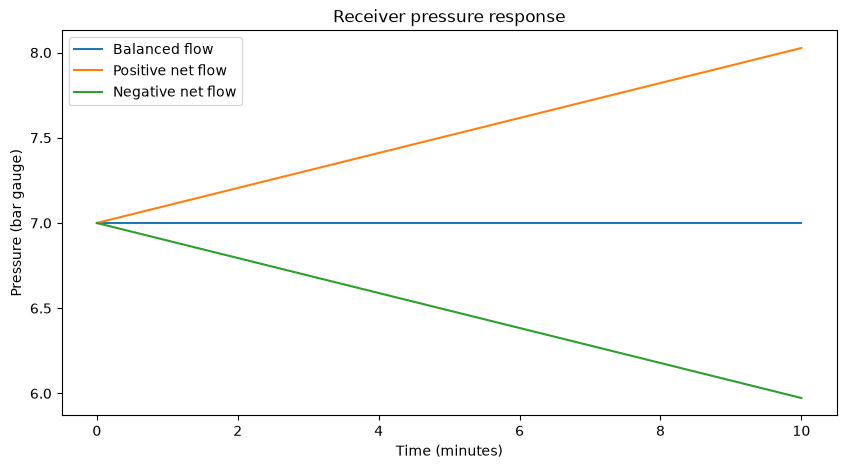

In [7]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    balanced["time_seconds"] / 60.0,
    balanced["pressure_bar_g"],
    label="Balanced flow",
)

ax.plot(
    pressure_rise[
        "time_seconds"
    ] / 60.0,
    pressure_rise[
        "pressure_bar_g"
    ],
    label="Positive net flow",
)

ax.plot(
    pressure_decay[
        "time_seconds"
    ] / 60.0,
    pressure_decay[
        "pressure_bar_g"
    ],
    label="Negative net flow",
)

ax.set_title(
    "Receiver pressure response"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Pressure (bar gauge)"
)

ax.legend()

plt.show()

## Leakage scenario

This simulation isolates the physical effect of changing leakage while holding compressor inflow and demand fixed.

A larger imposed leak causes a larger mass deficit and therefore lower receiver pressure. This is **not** evidence that any specific MetroPT incident was caused by leakage.

In [8]:
normal_leak = (
    simulate_constant_flow(
        duration_seconds=600,
        initial_pressure_bar_g=7.0,
        mass_flow_in_kg_s=0.10,
        demand_mass_flow_kg_s=0.09,
        leak_mass_flow_kg_s=0.005,
    )
)

high_leak = (
    simulate_constant_flow(
        duration_seconds=600,
        initial_pressure_bar_g=7.0,
        mass_flow_in_kg_s=0.10,
        demand_mass_flow_kg_s=0.09,
        leak_mass_flow_kg_s=0.02,
    )
)

normal_final = float(
    normal_leak[
        "pressure_bar_g"
    ].iloc[-1]
)

high_leak_final = float(
    high_leak[
        "pressure_bar_g"
    ].iloc[-1]
)

print(
    "Lower-leak final pressure:",
    normal_final,
)

print(
    "Higher-leak final pressure:",
    high_leak_final,
)

print(
    "Additional pressure loss:",
    normal_final
    - high_leak_final,
    "bar",
)

Lower-leak final pressure: 7.256751872500172
Higher-leak final pressure: 6.486496254999656
Additional pressure loss: 0.7702556175005162 bar


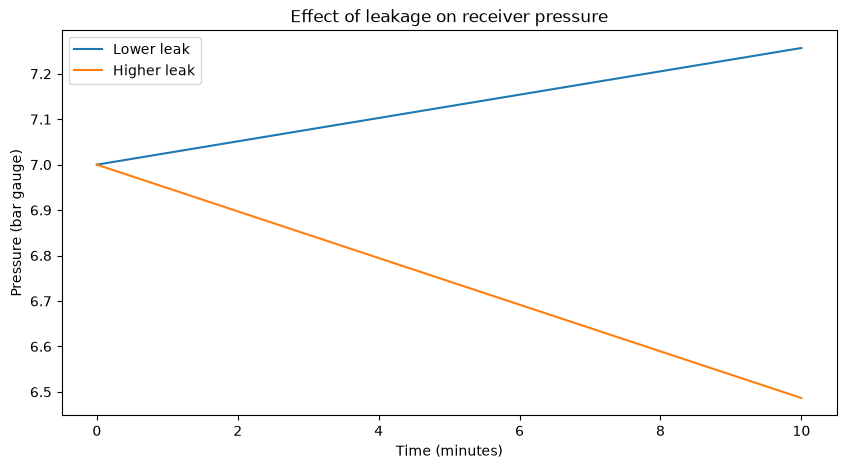

In [9]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    normal_leak[
        "time_seconds"
    ] / 60.0,
    normal_leak[
        "pressure_bar_g"
    ],
    label="Lower leak",
)

ax.plot(
    high_leak[
        "time_seconds"
    ] / 60.0,
    high_leak[
        "pressure_bar_g"
    ],
    label="Higher leak",
)

ax.set_title(
    "Effect of leakage on receiver pressure"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Pressure (bar gauge)"
)

ax.legend()

plt.show()

## Demand-step scenario

The first five minutes have compressor inflow greater than demand plus leakage, so receiver pressure rises. After the demand increase, demand plus leakage exceeds compressor inflow and pressure falls.

In [10]:
initial_pressure_pa = (
    bar_g_to_absolute_pa(
        7.0,
        ambient_pressure_pa=(
            parameters
            .ambient_pressure_pa
        ),
    )
)

pressure_pa = initial_pressure_pa

demand_rows = []

for second in range(
    0,
    601,
):
    demand = (
        0.08
        if second < 300
        else 0.11
    )

    demand_rows.append(
        {
            "time_seconds":
                float(second),
            "demand_mass_flow_kg_s":
                demand,
            "pressure_bar_g":
                absolute_pa_to_bar_g(
                    pressure_pa,
                    ambient_pressure_pa=(
                        parameters
                        .ambient_pressure_pa
                    ),
                ),
        }
    )

    if second == 600:
        break

    pressure_pa = step_pressure(
        pressure_pa=pressure_pa,
        mass_flow_in_kg_s=0.10,
        demand_mass_flow_kg_s=(
            demand
        ),
        leak_mass_flow_kg_s=0.01,
        timestep_seconds=1.0,
        parameters=parameters,
    )

demand_step = pd.DataFrame(
    demand_rows
)

demand_step.tail()

,time_seconds,demand_mass_flow_kg_s,pressure_bar_g
596,596.0,0.11,6.750095
597,597.0,0.11,6.748383
598,598.0,0.11,6.746671
599,599.0,0.11,6.744960
600,600.0,0.11,6.743248


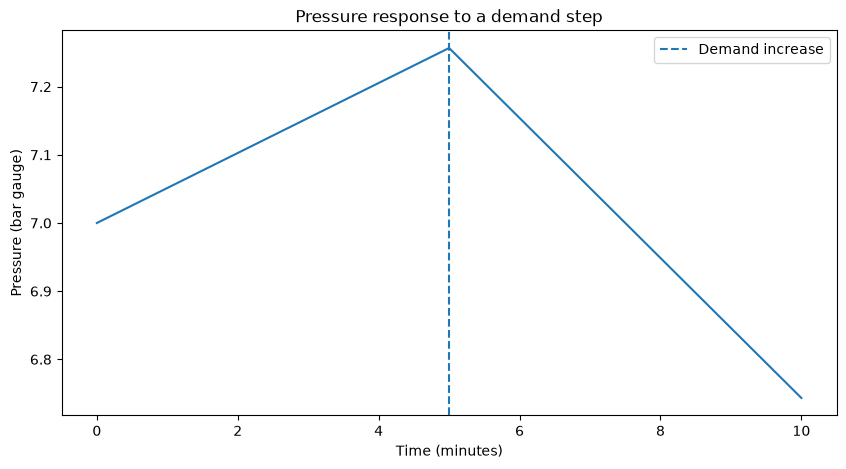

In [11]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    demand_step[
        "time_seconds"
    ] / 60.0,
    demand_step[
        "pressure_bar_g"
    ],
)

ax.axvline(
    5.0,
    linestyle="--",
    label="Demand increase",
)

ax.set_title(
    "Pressure response to a demand step"
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Pressure (bar gauge)"
)

ax.legend()

plt.show()

## Write simulated digital-twin evidence

The report below intentionally labels this evidence as simulated and records the assumptions and limitations needed for later API, UI, and ESIC presentation work.

In [12]:
REPORT_PATH = (
    ROOT
    / "docs"
    / "digital_twin_report.json"
)

report = {
    "evidence_class": "simulated",

    "model": {
        "equation": (
            "dp_dt = (R*T/V) * "
            "(m_in - m_demand - m_leak)"
        ),
        "temperature_assumption":
            "constant",
        "gas_assumption":
            "ideal gas",
        "receiver_assumption":
            "lumped constant-volume receiver",
    },

    "parameters": {
        "volume_m3":
            parameters.volume_m3,
        "temperature_k":
            parameters.temperature_k,
        "gas_constant_j_per_kg_k":
            parameters
            .gas_constant_j_per_kg_k,
        "ambient_pressure_pa":
            parameters
            .ambient_pressure_pa,
        "timestep_seconds":
            timestep_seconds,
    },

    "validation": {
        "balanced_pressure_change_bar":
            balanced_change_bar,
        "rise_10min_bar":
            rise_change,
        "decay_10min_bar":
            decay_change,
        "analytical_error_pa":
            absolute_error_pa,
    },

    "leak_scenario": {
        "lower_leak_kg_s":
            0.005,
        "higher_leak_kg_s":
            0.02,
        "lower_leak_final_bar_g":
            normal_final,
        "higher_leak_final_bar_g":
            high_leak_final,
        "pressure_difference_bar":
            normal_final
            - high_leak_final,
    },

    "limitations": [
        (
            "Parameters are simulation "
            "assumptions, not measurements "
            "from MetroPT or a factory."
        ),
        (
            "Temperature is assumed constant."
        ),
        (
            "Compressor flow is externally "
            "specified and not yet pressure-"
            "dependent."
        ),
        (
            "Leak flow is externally specified "
            "and not yet pressure-dependent."
        ),
        (
            "No compressor power or energy "
            "model is included yet."
        ),
        (
            "No controller or optimizer is "
            "included yet."
        ),
    ],
}

REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_PATH.write_text(
    json.dumps(
        report,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Digital twin report written to:",
    REPORT_PATH,
)

Digital twin report written to: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor/docs/digital_twin_report.json


## Interpretation

This notebook establishes only the pressure mass-balance layer of the digital twin.

The next layer should add compressor operating states, flow capacity, power consumption, and a conventional pressure-band controller. Energy optimization should be added only after that baseline behavior is validated.